<bound method NDFrame.head of      year month  passengers
0    1949   Jan         112
1    1949   Feb         118
2    1949   Mar         132
3    1949   Apr         129
4    1949   May         121
..    ...   ...         ...
139  1960   Aug         606
140  1960   Sep         508
141  1960   Oct         461
142  1960   Nov         390
143  1960   Dec         432

[144 rows x 3 columns]>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
 3   yearMonth   144 non-null    object  
dtypes: category(1), int64(2), object(1)
memory usage: 4.0+ KB
None
   year month  passengers    yearMonth
0  1949   Jan         112  01-Jan-1949
1  1949   Feb         118  01-Feb-1949
2  1949   Mar         132  01-Mar-1949
3  1949   Apr         129  01

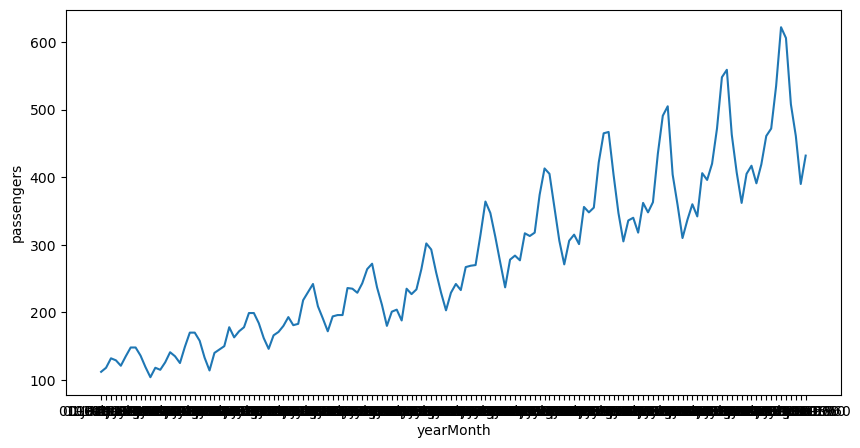

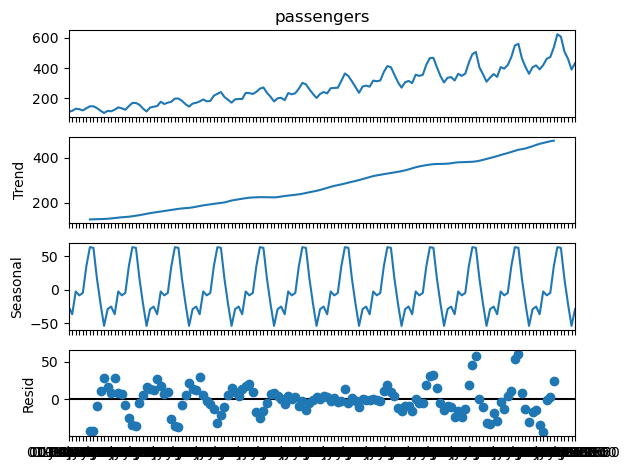

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('flights')
print(df.head)

# we get only year and month for the date , we need also
# convert tje date to YYYY-MM-DD format
df['yearMonth'] = '01-'+df['month'].astype(str)+'-'+df['year'].astype(str)
print(df.info())
print(df.head())

# make yearMonth column as dataframe index 
df.set_index('yearMonth', inplace=True) # inplace will make permanent change in dataframe
print(df.head())

# step 2: visualize the timeseries 
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x=df.index, y=df.passengers)
plt.show()

from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df.passengers,period=12)
fig = decomposition.plot()
plt.show()